## CEAS-08 Dataset, Real Data, Synthetic with Rewriting vs Combined Embeddings

## Data Prepare

In [2]:
import pandas as pd
import numpy as np
import gzip
import pickle
import os
from pathlib import Path

def combine_malicious_data(train_file, synthetic_files, output_file):
    """
    Part 1: Load and combine all malicious data with type labels
    """
    print("=== PART 1: COMBINING MALICIOUS DATA ===")
    
    # Create output directory if it doesn't exist
    Path(output_file).parent.mkdir(parents=True, exist_ok=True)
    
    # Load real world data (only malicious)
    print("Loading real world data...")
    real_data = pd.read_csv(train_file, compression='gzip')
    real_malicious = real_data[real_data['label'] == 1].copy()
    real_malicious['type'] = 'real'
    print(f"Real malicious samples: {len(real_malicious)}")
    
    # Combine all datasets
    all_malicious = [real_malicious[['subject', 'body', 'label', 'type']]]
    
    # Load synthetic data
    for data_type, file_path in synthetic_files.items():
        print(f"Loading {data_type} data...")
        synthetic_data = pd.read_csv(file_path, compression='gzip')
        synthetic_data['type'] = data_type
        all_malicious.append(synthetic_data[['subject', 'body', 'label', 'type']])
        print(f"{data_type} samples: {len(synthetic_data)}")
    
    # Combine all data
    combined_data = pd.concat(all_malicious, ignore_index=True)
    
    # Save combined data
    combined_data.to_csv(output_file, compression='gzip', index=False)
    print(f"\nCombined data saved to: {output_file}")
    print(f"Total combined samples: {len(combined_data)}")
    print("\nData type distribution:")
    print(combined_data['type'].value_counts())
    
    return combined_data

# Usage for Part 1
if __name__ == "__main__":
    # File paths
    TRAIN_FILE = "../raw/email_phishing_CEAS-08_train.csv.gz"
    SYNTHETIC_FILES = {
        'rewrite': "../data/rewrite/email_phishing_CEAS-08_malicious_original_rewritten.csv.gz",
        'rewrite_strong': "../data/rewrite/email_phishing_CEAS-08_malicious_strong_rewritten.csv.gz",
        'rewrite_weak': "../data/rewrite/email_phishing_CEAS-08_malicious_weak_rewritten.csv.gz"
    }
    COMBINED_FILE = "../data/embedding/email_phishing_CEAS-08_combined_malicious.csv.gz"
    
    # Run Part 1
    combined_data = combine_malicious_data(TRAIN_FILE, SYNTHETIC_FILES, COMBINED_FILE)

=== PART 1: COMBINING MALICIOUS DATA ===
Loading real world data...
Real malicious samples: 1000
Loading rewrite data...
rewrite samples: 1000
Loading rewrite_strong data...
rewrite_strong samples: 1000
Loading rewrite_weak data...
rewrite_weak samples: 1000

Combined data saved to: ../data/embedding/email_phishing_CEAS-08_combined_malicious.csv.gz
Total combined samples: 4000

Data type distribution:
type
real              1000
rewrite           1000
rewrite_strong    1000
rewrite_weak      1000
Name: count, dtype: int64


## Embedding Generations

In [3]:
from sentence_transformers import SentenceTransformer

def generate_embeddings(combined_file, embeddings_file, model_name='all-MiniLM-L6-v2'):
    """
    Part 2: Generate embeddings using sentence transformer
    """
    print("=== PART 2: GENERATING EMBEDDINGS ===")
    
    # Create output directory if it doesn't exist
    Path(embeddings_file).parent.mkdir(parents=True, exist_ok=True)
    
    print(f"Loading sentence transformer model: {model_name}")
    sentence_transformer = SentenceTransformer(model_name)
    
    print("Loading combined data...")
    combined_data = pd.read_csv(combined_file, compression='gzip')
    
    # Combine subject and body for embedding
    print("Preparing text for embedding...")
    combined_text = combined_data['subject'].fillna('') + ' ' + combined_data['body'].fillna('')
    
    print("Generating embeddings...")
    embeddings = sentence_transformer.encode(
        combined_text.tolist(), 
        show_progress_bar=True,
        batch_size=32
    )
    
    # Save embeddings with metadata
    embedding_data = {
        'embeddings': embeddings,
        'types': combined_data['type'].values,
        'indices': combined_data.index.values,
        'model_name': model_name,
        'embedding_dim': embeddings.shape[1],
        'data_shape': embeddings.shape,
        'type_counts': combined_data['type'].value_counts().to_dict()
    }
    
    with open(embeddings_file, 'wb') as f:
        pickle.dump(embedding_data, f)
    
    print(f"\nEmbeddings saved to: {embeddings_file}")
    print(f"Embedding shape: {embeddings.shape}")
    print(f"Model used: {model_name}")
    
    return embedding_data

# Usage for Part 2
if __name__ == "__main__":
    COMBINED_FILE = "../data/embedding/email_phishing_CEAS-08_combined_malicious.csv.gz"
    EMBEDDINGS_FILE = "../data/embedding/combined_CEAS-08_malicious_all-MiniLM-L6-v2_embeddings.pkl"
    
    # Run Part 2 (only if embeddings don't exist)
    if not os.path.exists(EMBEDDINGS_FILE):
        embedding_data = generate_embeddings(COMBINED_FILE, EMBEDDINGS_FILE)
    else:
        print(f"Embeddings already exist at: {EMBEDDINGS_FILE}")

c:\Users\Tianyu Wang\AppData\Local\pypoetry\Cache\virtualenvs\cyberdata-AovS1HFQ-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== PART 2: GENERATING EMBEDDINGS ===
Loading sentence transformer model: all-MiniLM-L6-v2
Loading combined data...
Preparing text for embedding...
Generating embeddings...


Batches: 100%|██████████| 125/125 [00:54<00:00,  2.31it/s]



Embeddings saved to: ../data/embedding/combined_CEAS-08_malicious_all-MiniLM-L6-v2_embeddings.pkl
Embedding shape: (4000, 384)
Model used: all-MiniLM-L6-v2


## Embedding Visualization

=== PART 1: COMBINING MALICIOUS DATA ===
Loading real world data...
Real malicious samples: 1000
Loading rewrite data...
rewrite samples: 1000
Loading rewrite_strong data...
rewrite_strong samples: 1000
Loading rewrite_weak data...
rewrite_weak samples: 1000

Combined data saved to: ../data/embedding/email_phishing_CEAS-08_combined_malicious.csv.gz
Total combined samples: 4000

Data type distribution:
type
real              1000
rewrite           1000
rewrite_strong    1000
rewrite_weak      1000
Name: count, dtype: int64


c:\Users\Tianyu Wang\AppData\Local\pypoetry\Cache\virtualenvs\cyberdata-AovS1HFQ-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embeddings already exist at: ../data/embedding/combined_CEAS-08_malicious_all-MiniLM-L6-v2_embeddings.pkl
=== PART 3: EMBEDDING ANALYSIS ===
Loading embeddings...
Loaded embeddings shape: (4000, 384)
Model used: all-MiniLM-L6-v2
Type distribution:
  real: 1000
  rewrite: 1000
  rewrite_strong: 1000
  rewrite_weak: 1000

📊 Computing basic statistics...
✅ Statistics computed successfully!

🔄 Performing dimensionality reduction...
  Applying PCA...
  Applying t-SNE...
✅ Dimensionality reduction completed!

🎯 Performing clustering analysis...
  K-means clustering...
  Optimal k based on silhouette score: 12
  Best silhouette score: 0.183
✅ Clustering analysis completed!

📈 Creating visualization dashboard...
📁 Visualization saved to: ../data/embedding/combined_CEAS-08_malicious_all-MiniLM-L6-v2_embeddings_analysis_dashboard.png


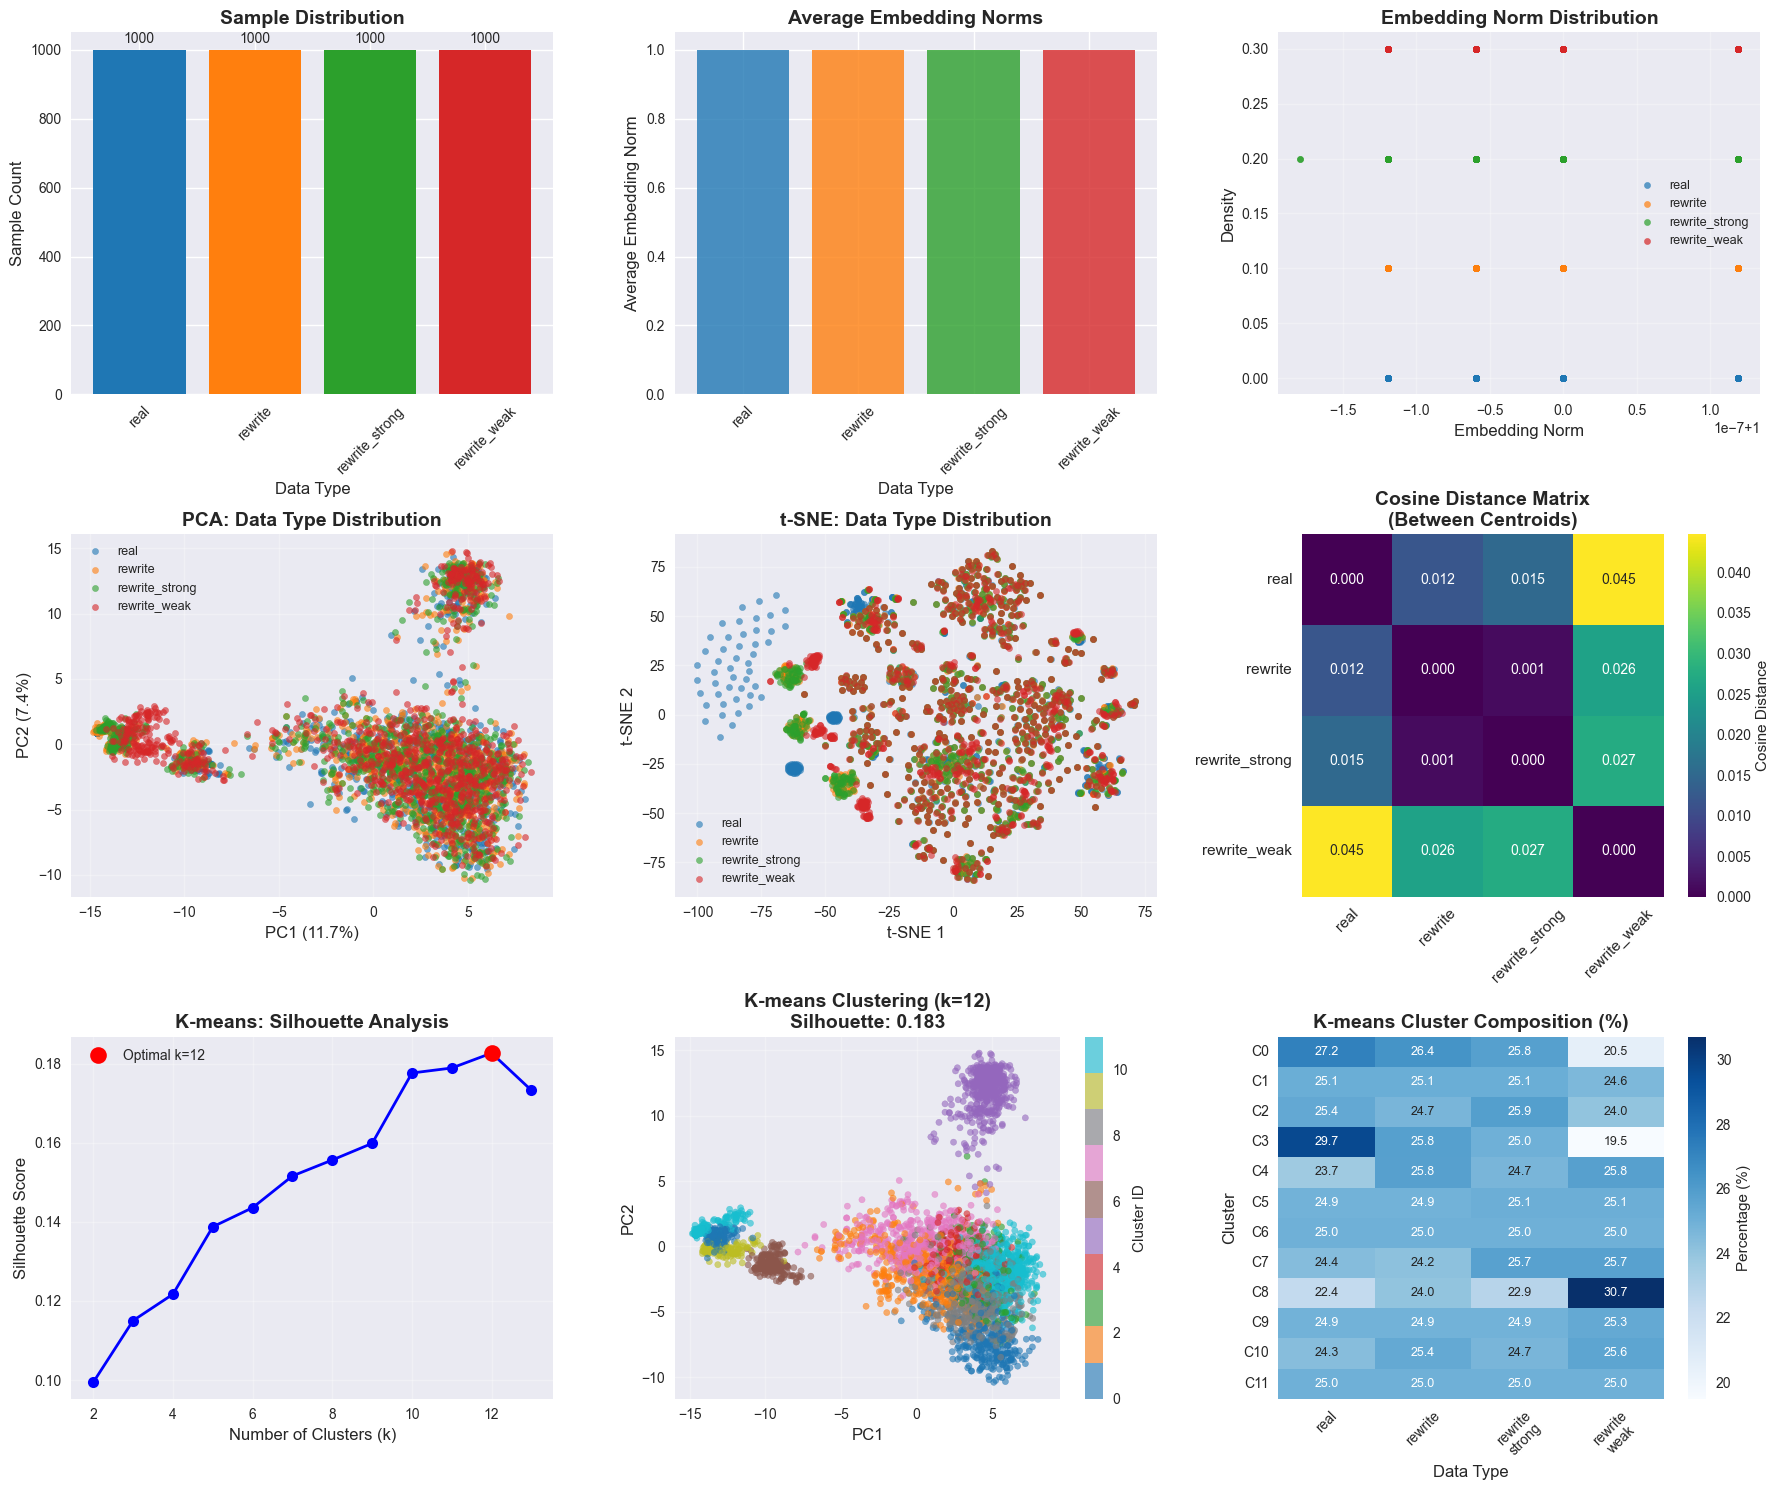


🎯 EMBEDDING ANALYSIS SUMMARY
📊 Total samples: 4000
📐 Embedding dimension: 384
🤖 Model used: all-MiniLM-L6-v2

🎯 Best K-means clusters: 12
📈 Best silhouette score: 0.183

📊 PCA explained variance: [0.11726741 0.07372081]
📈 Total variance explained: 19.1%

📋 Sample counts by data type:
  real: 1000
  rewrite: 1000
  rewrite_strong: 1000
  rewrite_weak: 1000

📏 Average embedding norms:
  real: 1.000 ± 0.000
  rewrite: 1.000 ± 0.000
  rewrite_strong: 1.000 ± 0.000
  rewrite_weak: 1.000 ± 0.000

📐 Cosine distance matrix (centroids):
                 real  rewrite  rewrite_strong  rewrite_weak
real            0.000    0.012           0.015         0.045
rewrite         0.012    0.000           0.001         0.026
rewrite_strong  0.015    0.001           0.000         0.027
rewrite_weak    0.045    0.026           0.027         0.000


In [1]:
import pandas as pd
import numpy as np
import gzip
import pickle
import os
from pathlib import Path

def combine_malicious_data(train_file, synthetic_files, output_file):
    """
    Part 1: Load and combine all malicious data with type labels
    """
    print("=== PART 1: COMBINING MALICIOUS DATA ===")
    
    # Create output directory if it doesn't exist
    Path(output_file).parent.mkdir(parents=True, exist_ok=True)
    
    # Load real world data (only malicious)
    print("Loading real world data...")
    real_data = pd.read_csv(train_file, compression='gzip')
    real_malicious = real_data[real_data['label'] == 1].copy()
    real_malicious['type'] = 'real'
    print(f"Real malicious samples: {len(real_malicious)}")
    
    # Combine all datasets
    all_malicious = [real_malicious[['subject', 'body', 'label', 'type']]]
    
    # Load synthetic data
    for data_type, file_path in synthetic_files.items():
        print(f"Loading {data_type} data...")
        synthetic_data = pd.read_csv(file_path, compression='gzip')
        synthetic_data['type'] = data_type
        all_malicious.append(synthetic_data[['subject', 'body', 'label', 'type']])
        print(f"{data_type} samples: {len(synthetic_data)}")
    
    # Combine all data
    combined_data = pd.concat(all_malicious, ignore_index=True)
    
    # Save combined data
    combined_data.to_csv(output_file, compression='gzip', index=False)
    print(f"\nCombined data saved to: {output_file}")
    print(f"Total combined samples: {len(combined_data)}")
    print("\nData type distribution:")
    print(combined_data['type'].value_counts())
    
    return combined_data

# Usage for Part 1
if __name__ == "__main__":
    # File paths
    TRAIN_FILE = "../raw/email_phishing_CEAS-08_train.csv.gz"
    SYNTHETIC_FILES = {
        'rewrite': "../data/rewrite/email_phishing_CEAS-08_malicious_original_rewritten.csv.gz",
        'rewrite_strong': "../data/rewrite/email_phishing_CEAS-08_malicious_strong_rewritten.csv.gz",
        'rewrite_weak': "../data/rewrite/email_phishing_CEAS-08_malicious_weak_rewritten.csv.gz"
    }
    COMBINED_FILE = "../data/embedding/email_phishing_CEAS-08_combined_malicious.csv.gz"
    
    # Run Part 1
    combined_data = combine_malicious_data(TRAIN_FILE, SYNTHETIC_FILES, COMBINED_FILE)



    from sentence_transformers import SentenceTransformer

def generate_embeddings(combined_file, embeddings_file, model_name='all-MiniLM-L6-v2'):
    """
    Part 2: Generate embeddings using sentence transformer
    """
    print("=== PART 2: GENERATING EMBEDDINGS ===")
    
    # Create output directory if it doesn't exist
    Path(embeddings_file).parent.mkdir(parents=True, exist_ok=True)
    
    print(f"Loading sentence transformer model: {model_name}")
    sentence_transformer = SentenceTransformer(model_name)
    
    print("Loading combined data...")
    combined_data = pd.read_csv(combined_file, compression='gzip')
    
    # Combine subject and body for embedding
    print("Preparing text for embedding...")
    combined_text = combined_data['subject'].fillna('') + ' ' + combined_data['body'].fillna('')
    
    print("Generating embeddings...")
    embeddings = sentence_transformer.encode(
        combined_text.tolist(), 
        show_progress_bar=True,
        batch_size=32
    )
    
    # Save embeddings with metadata
    embedding_data = {
        'embeddings': embeddings,
        'types': combined_data['type'].values,
        'indices': combined_data.index.values,
        'model_name': model_name,
        'embedding_dim': embeddings.shape[1],
        'data_shape': embeddings.shape,
        'type_counts': combined_data['type'].value_counts().to_dict()
    }
    
    with open(embeddings_file, 'wb') as f:
        pickle.dump(embedding_data, f)
    
    print(f"\nEmbeddings saved to: {embeddings_file}")
    print(f"Embedding shape: {embeddings.shape}")
    print(f"Model used: {model_name}")
    
    return embedding_data

# Usage for Part 2
if __name__ == "__main__":
    COMBINED_FILE = "../data/embedding/email_phishing_CEAS-08_combined_malicious.csv.gz"
    EMBEDDINGS_FILE = "../data/embedding/combined_CEAS-08_malicious_all-MiniLM-L6-v2_embeddings.pkl"
    
    # Run Part 2 (only if embeddings don't exist)
    if not os.path.exists(EMBEDDINGS_FILE):
        embedding_data = generate_embeddings(COMBINED_FILE, EMBEDDINGS_FILE)
    else:
        print(f"Embeddings already exist at: {EMBEDDINGS_FILE}")



# part3_analysis_visualization.py
"""
CyberDataGen Analysis - Part 3: Comprehensive Analysis and Visualization
"""

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.spatial.distance import cosine
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('seaborn')
sns.set_palette("husl")

class EmbeddingAnalyzer:
    def __init__(self, embeddings_file):
        """
        Load embeddings and initialize analyzer
        """
        print("=== PART 3: EMBEDDING ANALYSIS ===")
        print("Loading embeddings...")
        
        with open(embeddings_file, 'rb') as f:
            self.embedding_data = pickle.load(f)
        
        self.embeddings = self.embedding_data['embeddings']
        self.types = self.embedding_data['types']
        self.data_types = ['real', 'rewrite', 'rewrite_strong', 'rewrite_weak']
        
        print(f"Loaded embeddings shape: {self.embeddings.shape}")
        print(f"Model used: {self.embedding_data['model_name']}")
        print("Type distribution:")
        for dtype in self.data_types:
            count = np.sum(self.types == dtype)
            print(f"  {dtype}: {count}")
    
    def compute_basic_statistics(self):
        """
        Compute basic statistics for each data type
        """
        print("\n📊 Computing basic statistics...")
        
        stats_results = {}
        for data_type in self.data_types:
            type_mask = self.types == data_type
            type_embeddings = self.embeddings[type_mask]
            
            stats_results[data_type] = {
                'count': len(type_embeddings),
                'mean_norm': np.mean(np.linalg.norm(type_embeddings, axis=1)),
                'std_norm': np.std(np.linalg.norm(type_embeddings, axis=1)),
                'mean_embedding': np.mean(type_embeddings, axis=0),
                'std_embedding': np.std(type_embeddings, axis=0)
            }
        
        # Calculate pairwise distances between centroids
        centroids = {dt: stats_results[dt]['mean_embedding'] for dt in self.data_types}
        distance_matrix = np.zeros((len(self.data_types), len(self.data_types)))
        
        for i, dt1 in enumerate(self.data_types):
            for j, dt2 in enumerate(self.data_types):
                distance_matrix[i, j] = cosine(centroids[dt1], centroids[dt2])
        
        self.stats_results = stats_results
        self.distance_matrix = distance_matrix
        
        print("✅ Statistics computed successfully!")
        return stats_results, distance_matrix
    
    def perform_dimensionality_reduction(self):
        """
        Perform PCA and t-SNE for visualization
        """
        print("\n🔄 Performing dimensionality reduction...")
        
        # Standardize embeddings
        scaler = StandardScaler()
        embeddings_scaled = scaler.fit_transform(self.embeddings)
        
        # PCA
        print("  Applying PCA...")
        pca = PCA(n_components=2, random_state=42)
        pca_embeddings = pca.fit_transform(embeddings_scaled)
        
        # t-SNE
        print("  Applying t-SNE...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        tsne_embeddings = tsne.fit_transform(embeddings_scaled)
        
        self.reduction_results = {
            'pca': {
                'embeddings': pca_embeddings,
                'explained_variance': pca.explained_variance_ratio_,
                'scaler': scaler
            },
            'tsne': {
                'embeddings': tsne_embeddings
            }
        }
        
        print("✅ Dimensionality reduction completed!")
        return self.reduction_results
    
    def perform_clustering_analysis(self, k_range=range(2, 14)):  # Updated range
        """
        Perform clustering analysis
        """
        print("\n🎯 Performing clustering analysis...")
        
        # Standardize embeddings
        scaler = StandardScaler()
        embeddings_scaled = scaler.fit_transform(self.embeddings)
        
        # K-means clustering
        print("  K-means clustering...")
        kmeans_scores = {}
        for n_clusters in k_range:
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            cluster_labels = kmeans.fit_predict(embeddings_scaled)
            
            silhouette_avg = silhouette_score(embeddings_scaled, cluster_labels)
            calinski_harabasz = calinski_harabasz_score(embeddings_scaled, cluster_labels)
            
            kmeans_scores[n_clusters] = {
                'silhouette': silhouette_avg,
                'calinski_harabasz': calinski_harabasz,
                'labels': cluster_labels
            }
        
        # Find optimal number of clusters using HIGHEST silhouette score
        best_k = max(kmeans_scores.keys(), 
                    key=lambda k: kmeans_scores[k]['silhouette'])
        
        print(f"  Optimal k based on silhouette score: {best_k}")
        print(f"  Best silhouette score: {kmeans_scores[best_k]['silhouette']:.3f}")
        
        self.clustering_results = {
            'kmeans': {
                'best_k': best_k,
                'all_scores': kmeans_scores,
                'best_labels': kmeans_scores[best_k]['labels']
            }
        }
        
        print("✅ Clustering analysis completed!")
        return self.clustering_results
    
    def analyze_cluster_composition(self, cluster_labels):
        """
        Analyze how clusters are composed of different data types
        """
        unique_clusters = np.unique(cluster_labels)
        composition_matrix = np.zeros((len(unique_clusters), len(self.data_types)))
        
        for i, cluster in enumerate(unique_clusters):
            cluster_mask = cluster_labels == cluster
            for j, data_type in enumerate(self.data_types):
                type_mask = self.types == data_type
                composition_matrix[i, j] = np.sum(cluster_mask & type_mask)
        
        # Convert to percentages
        composition_pct = composition_matrix / composition_matrix.sum(axis=1, keepdims=True) * 100
        
        return composition_matrix, composition_pct
    
    def create_visualization_dashboard(self, save_path=None):
        """
        Create comprehensive visualization dashboard - Reorganized layout
        """
        print("\n📈 Creating visualization dashboard...")
        
        # Set up the plot with 3x3 grid
        fig = plt.figure(figsize=(18, 15))
        
        # Color palette for data types
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        type_colors = {dt: colors[i] for i, dt in enumerate(self.data_types)}
        
        # ROW 1: Sample distribution, Average embedding norms, Embedding norm distribution
        
        # 1. Sample counts
        plt.subplot(3, 3, 1)
        counts = [self.stats_results[dt]['count'] for dt in self.data_types]
        bars = plt.bar(self.data_types, counts, color=colors)
        plt.xlabel('Data Type', fontsize=12)
        plt.ylabel('Sample Count', fontsize=12)
        plt.title('Sample Distribution', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, fontsize=10)
        plt.yticks(fontsize=10)
        # Add count labels on bars
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                    str(count), ha='center', va='bottom', fontsize=10)
        
        # 2. Average norms with error bars
        plt.subplot(3, 3, 2)
        mean_norms = [self.stats_results[dt]['mean_norm'] for dt in self.data_types]
        std_norms = [self.stats_results[dt]['std_norm'] for dt in self.data_types]
        bars = plt.bar(self.data_types, mean_norms, yerr=std_norms, 
                      color=colors, capsize=5, alpha=0.8)
        plt.xlabel('Data Type', fontsize=12)
        plt.ylabel('Average Embedding Norm', fontsize=12)
        plt.title('Average Embedding Norms', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, fontsize=10)
        plt.yticks(fontsize=10)
        
        # 3. Embedding norm distribution
        plt.subplot(3, 3, 3)
        for i, data_type in enumerate(self.data_types):
            type_mask = self.types == data_type
            type_embeddings = self.embeddings[type_mask]
            norms = np.linalg.norm(type_embeddings, axis=1)
            
            # Check if we have enough data variability for histogram
            unique_norms = np.unique(norms)
            if len(unique_norms) <= 1:
                # If all values are the same, just plot a vertical line
                plt.axvline(norms[0], color=colors[i], alpha=0.7, 
                           linewidth=3, label=data_type)
            else:
                # Use the number of unique values as bins, but cap it
                n_bins = min(20, len(unique_norms))
                try:
                    plt.hist(norms, alpha=0.7, bins=n_bins, label=data_type, 
                            density=True, color=colors[i])
                except ValueError:
                    # If histogram still fails, plot as scatter
                    y_pos = np.full_like(norms, i * 0.1)
                    plt.scatter(norms, y_pos, alpha=0.7, color=colors[i], 
                              label=data_type, s=20)
        plt.xlabel('Embedding Norm', fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.title('Embedding Norm Distribution', fontsize=14, fontweight='bold')
        plt.legend(fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        
        # ROW 2: PCA, t-SNE, Cosine distance matrix
        
        # 4. PCA visualization by data type
        plt.subplot(3, 3, 4)
        pca_embeddings = self.reduction_results['pca']['embeddings']
        for i, data_type in enumerate(self.data_types):
            type_mask = self.types == data_type
            plt.scatter(pca_embeddings[type_mask, 0], pca_embeddings[type_mask, 1], 
                       label=data_type, alpha=0.6, s=20, c=colors[i])
        plt.xlabel(f'PC1 ({self.reduction_results["pca"]["explained_variance"][0]:.1%})', fontsize=12)
        plt.ylabel(f'PC2 ({self.reduction_results["pca"]["explained_variance"][1]:.1%})', fontsize=12)
        plt.title('PCA: Data Type Distribution', fontsize=14, fontweight='bold')
        plt.legend(fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        
        # 5. t-SNE visualization by data type
        plt.subplot(3, 3, 5)
        tsne_embeddings = self.reduction_results['tsne']['embeddings']
        for i, data_type in enumerate(self.data_types):
            type_mask = self.types == data_type
            plt.scatter(tsne_embeddings[type_mask, 0], tsne_embeddings[type_mask, 1], 
                       label=data_type, alpha=0.6, s=20, c=colors[i])
        plt.xlabel('t-SNE 1', fontsize=12)
        plt.ylabel('t-SNE 2', fontsize=12)
        plt.title('t-SNE: Data Type Distribution', fontsize=14, fontweight='bold')
        plt.legend(fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        
        # 6. Distance matrix heatmap
        plt.subplot(3, 3, 6)
        sns.heatmap(self.distance_matrix, annot=True, fmt='.3f', 
                   xticklabels=self.data_types, yticklabels=self.data_types,
                   cmap='viridis', square=True, annot_kws={'fontsize': 10},
                   cbar_kws={'label': 'Cosine Distance'})
        plt.title('Cosine Distance Matrix\n(Between Centroids)', fontsize=14, fontweight='bold')
        plt.xticks(fontsize=11, rotation=45)
        plt.yticks(fontsize=11, rotation=0)
        
        # ROW 3: Silhouette analysis, K-means clustering, K-means cluster composition
        
        # 7. Silhouette scores with optimal k highlighted
        plt.subplot(3, 3, 7)
        k_values = list(self.clustering_results['kmeans']['all_scores'].keys())
        silhouette_scores = [self.clustering_results['kmeans']['all_scores'][k]['silhouette'] 
                           for k in k_values]
        
        plt.plot(k_values, silhouette_scores, 'bo-', linewidth=2, markersize=8)
        
        # Highlight the optimal k
        best_k = self.clustering_results['kmeans']['best_k']
        best_score = self.clustering_results['kmeans']['all_scores'][best_k]['silhouette']
        plt.plot(best_k, best_score, 'ro', markersize=12, label=f'Optimal k={best_k}')
        
        plt.xlabel('Number of Clusters (k)', fontsize=12)
        plt.ylabel('Silhouette Score', fontsize=12)
        plt.title('K-means: Silhouette Analysis', fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        
        # 8. K-means clustering (colored by cluster ID)
        plt.subplot(3, 3, 8)
        best_k = self.clustering_results['kmeans']['best_k']
        cluster_labels = self.clustering_results['kmeans']['best_labels']
        scatter = plt.scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], 
                            c=cluster_labels, cmap='tab10', alpha=0.6, s=20)
        plt.xlabel('PC1', fontsize=12)
        plt.ylabel('PC2', fontsize=12)
        plt.title(f'K-means Clustering (k={best_k})\nSilhouette: {self.clustering_results["kmeans"]["all_scores"][best_k]["silhouette"]:.3f}', 
                 fontsize=14, fontweight='bold')
        cbar = plt.colorbar(scatter, label='Cluster ID')
        cbar.ax.tick_params(labelsize=10)
        plt.grid(True, alpha=0.3)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        
        # 9. K-means cluster composition - improved formatting
        plt.subplot(3, 3, 9)
        kmeans_composition, kmeans_pct = self.analyze_cluster_composition(cluster_labels)
        
        # Create better labels for clusters
        cluster_labels_formatted = [f'C{i}' for i in range(len(kmeans_pct))]
        data_type_labels = [dt.replace('_', '\n') for dt in self.data_types]  # Break long labels
        
        sns.heatmap(kmeans_pct, annot=True, fmt='.1f', 
                   xticklabels=data_type_labels, 
                   yticklabels=cluster_labels_formatted,
                   cmap='Blues', square=False, annot_kws={'fontsize': 9},
                   cbar_kws={'label': 'Percentage (%)'})
        plt.title('K-means Cluster Composition (%)', fontsize=14, fontweight='bold')
        plt.xlabel('Data Type', fontsize=12)
        plt.ylabel('Cluster', fontsize=12)
        plt.xticks(fontsize=10, rotation=45)
        plt.yticks(fontsize=10, rotation=0)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📁 Visualization saved to: {save_path}")
        
        plt.show()
        
        return fig
    
    def print_analysis_summary(self):
        """
        Print comprehensive analysis summary
        """
        print("\n" + "="*60)
        print("🎯 EMBEDDING ANALYSIS SUMMARY")
        print("="*60)
        
        print(f"📊 Total samples: {len(self.embeddings)}")
        print(f"📐 Embedding dimension: {self.embeddings.shape[1]}")
        print(f"🤖 Model used: {self.embedding_data['model_name']}")
        
        print(f"\n🎯 Best K-means clusters: {self.clustering_results['kmeans']['best_k']}")
        print(f"📈 Best silhouette score: {max([s['silhouette'] for s in self.clustering_results['kmeans']['all_scores'].values()]):.3f}")
        
        print(f"\n📊 PCA explained variance: {self.reduction_results['pca']['explained_variance']}")
        print(f"📈 Total variance explained: {sum(self.reduction_results['pca']['explained_variance']):.1%}")
        
        print("\n📋 Sample counts by data type:")
        for dt in self.data_types:
            print(f"  {dt}: {self.stats_results[dt]['count']}")
        
        print("\n📏 Average embedding norms:")
        for dt in self.data_types:
            mean_norm = self.stats_results[dt]['mean_norm']
            std_norm = self.stats_results[dt]['std_norm']
            print(f"  {dt}: {mean_norm:.3f} ± {std_norm:.3f}")
        
        print("\n📐 Cosine distance matrix (centroids):")
        df_distance = pd.DataFrame(self.distance_matrix, 
                                 index=self.data_types, 
                                 columns=self.data_types)
        print(df_distance.round(3))

def run_analysis_from_embeddings(embeddings_file, save_viz=True):
    """
    Quick function to run analysis from existing embeddings
    """
    # Initialize analyzer
    analyzer = EmbeddingAnalyzer(embeddings_file)
    
    # Run all analyses
    stats_results, distance_matrix = analyzer.compute_basic_statistics()
    reduction_results = analyzer.perform_dimensionality_reduction()
    clustering_results = analyzer.perform_clustering_analysis()
    
    # Create visualizations
    save_path = None
    if save_viz:
        save_path = embeddings_file.replace('.pkl', '_analysis_dashboard.png')
    
    fig = analyzer.create_visualization_dashboard(save_path=save_path)
    
    # Print summary
    analyzer.print_analysis_summary()
    
    return analyzer

if __name__ == "__main__":
    # Configuration
    EMBEDDINGS_FILE = "../data/embedding/combined_CEAS-08_malicious_all-MiniLM-L6-v2_embeddings.pkl"
    
    # Run analysis
    analyzer = run_analysis_from_embeddings(EMBEDDINGS_FILE)

## Interactive Embedding Visualization